In [3]:
import torch

from cryosim import atom, potential
from cryosim.pdbtools import PDB
from cryosim.plotting_tools import plot3d, plot_slices
from cryosim.potential import PotentialBuilder

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Download PDB file

In [5]:
folder = "../pdb-data/"
filename = PDB.fetch_pdb_file("6bdf", savefolder=folder)
filename

Assemblies available: 1
6bdf: Fetching default Biological Assembly 1
File already exists: ../pdb-data/6bdf-assembly1.cif, skip fetching.


'../pdb-data/6bdf-assembly1.cif'

## Extract atomic coordinates and recenter onto (0,0,0)

In [8]:
# extracts raw coordinates for each atom in (x,y,z) order from pdb file
assemble = True
atomic_numbers, coords = PDB.get_atoms_and_coordinates(filename)
atomic_numbers.shape, coords.shape

Output()

(torch.Size([46382]), torch.Size([46382, 3]))

In [9]:
# elements in particle
print(set(atom.atom_symbol(atomic_numbers)))

{'N', 'O', 'C', 'S'}


In [10]:
coords.shape

torch.Size([46382, 3])

In [12]:
# recenters coordinates onto origin (0,0,0)
center = PDB.center_of_particle(coords)
centered_coords = coords - center.reshape(1, -1)

## Convolution method

In [13]:
n = 256
dx = 1
vol_3d, occupancy, atomic_potentials = potential.build_potential_volume_fftconvolve_3d(
    atomic_numbers,
    centered_coords,
    n,
    dx,
)

Output()

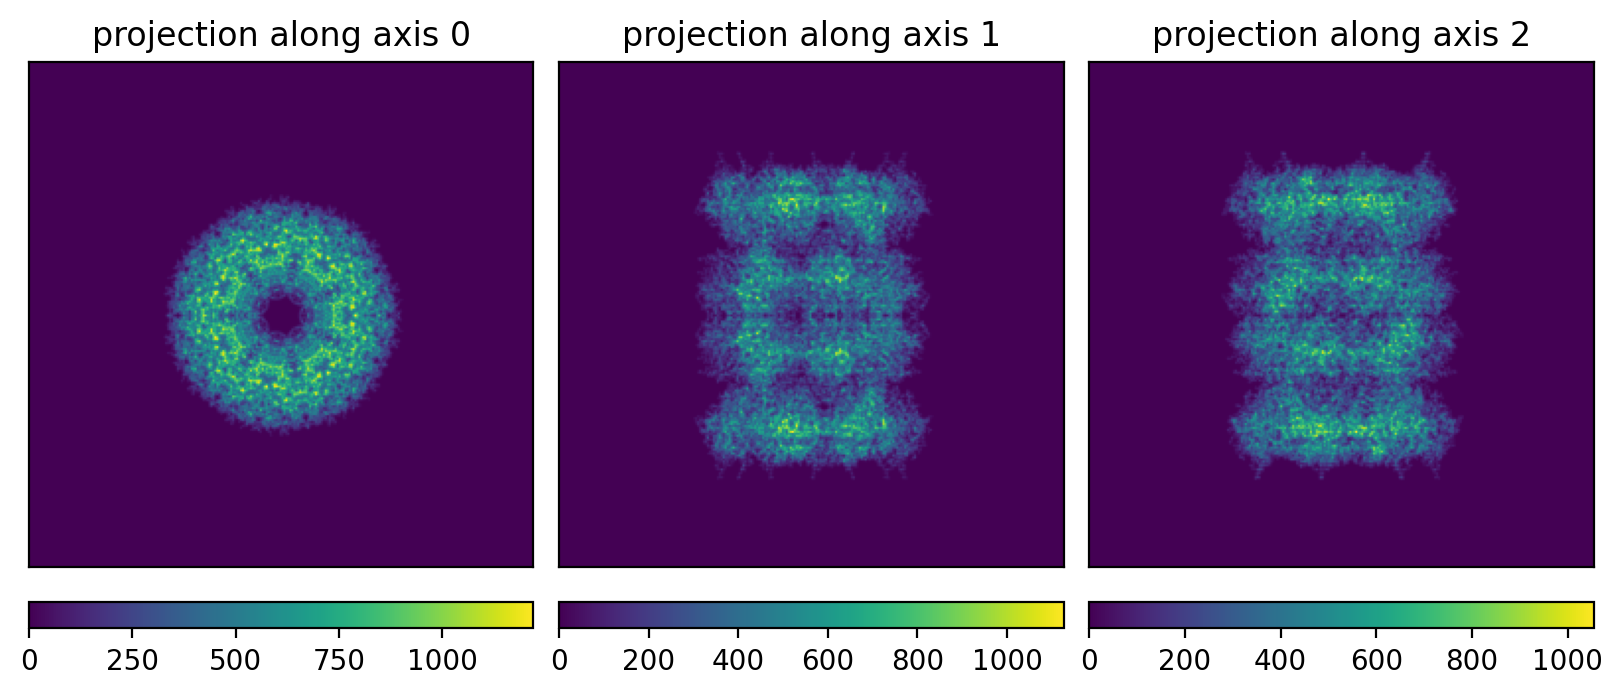

In [14]:
plot3d(vol_3d)

In [15]:
vol_2d, occupancy, atomic_potentials = potential.build_potential_volume_fftconvolve_2d(
    atomic_numbers,
    centered_coords,
    n,
    dx,
)

Output()

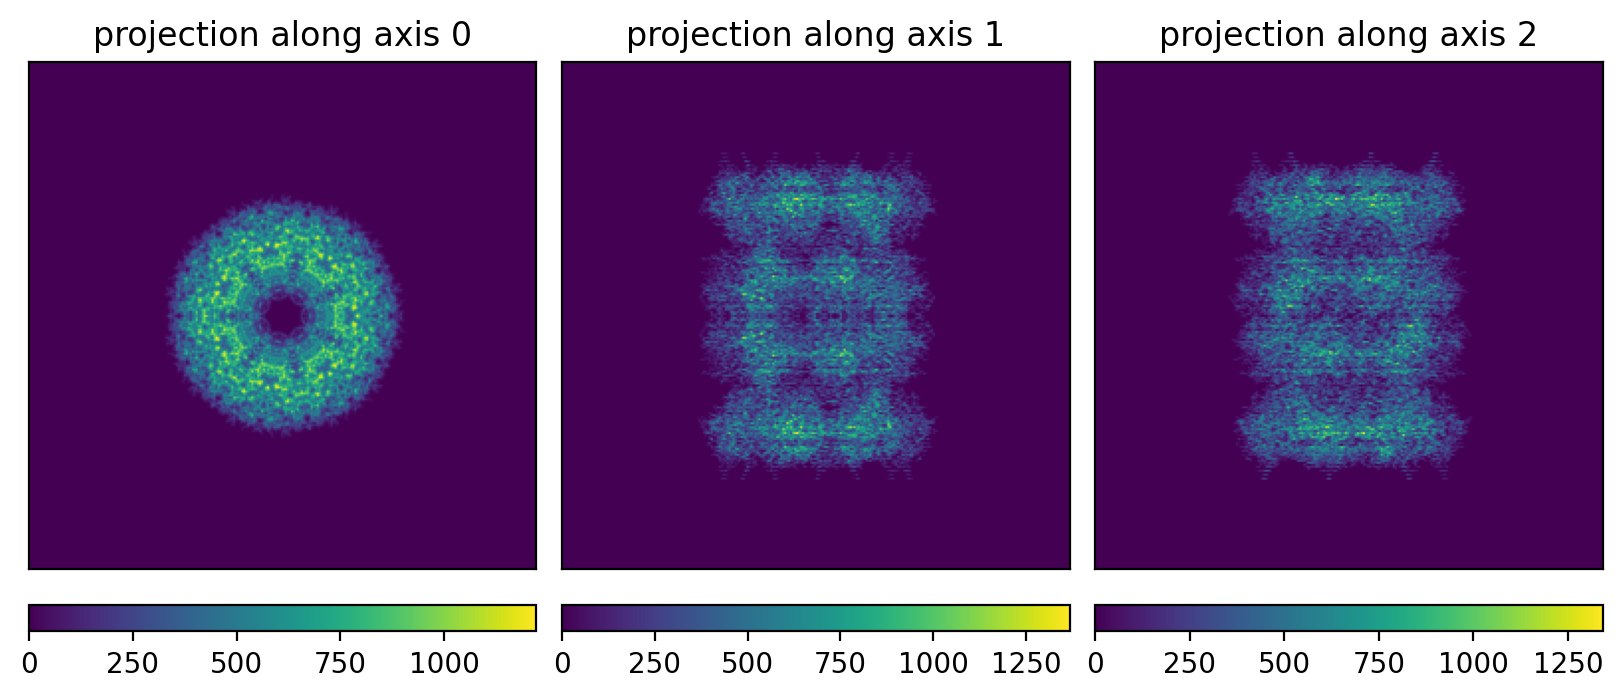

In [16]:
plot3d(vol_2d)

## Compare error between 2D and 3D

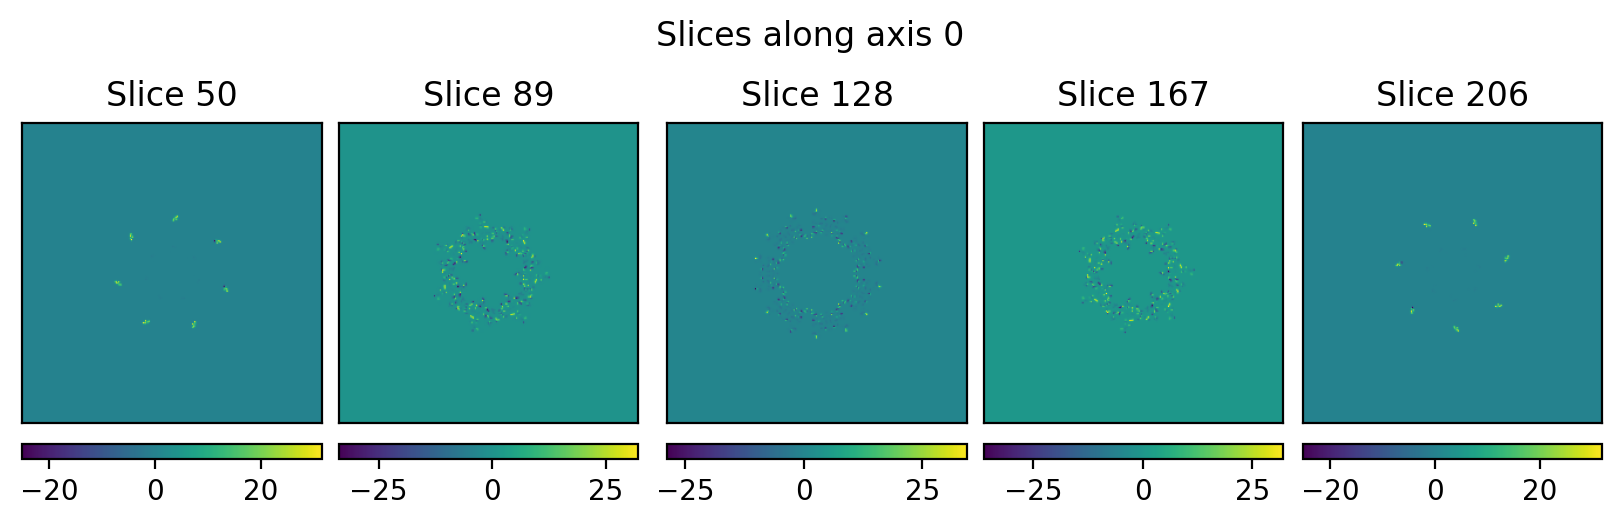

In [17]:
start_idx = 50
plot_slices(vol_2d - vol_3d, start_idx=start_idx, end_idx=n - start_idx)

## PotentialBuilder class

In [18]:
device = "cuda"
pb = PotentialBuilder(n, dx, atomic_numbers, centered_coords).to(device)

In [19]:
with torch.no_grad():
    vol = pb(method="3d")

Output()

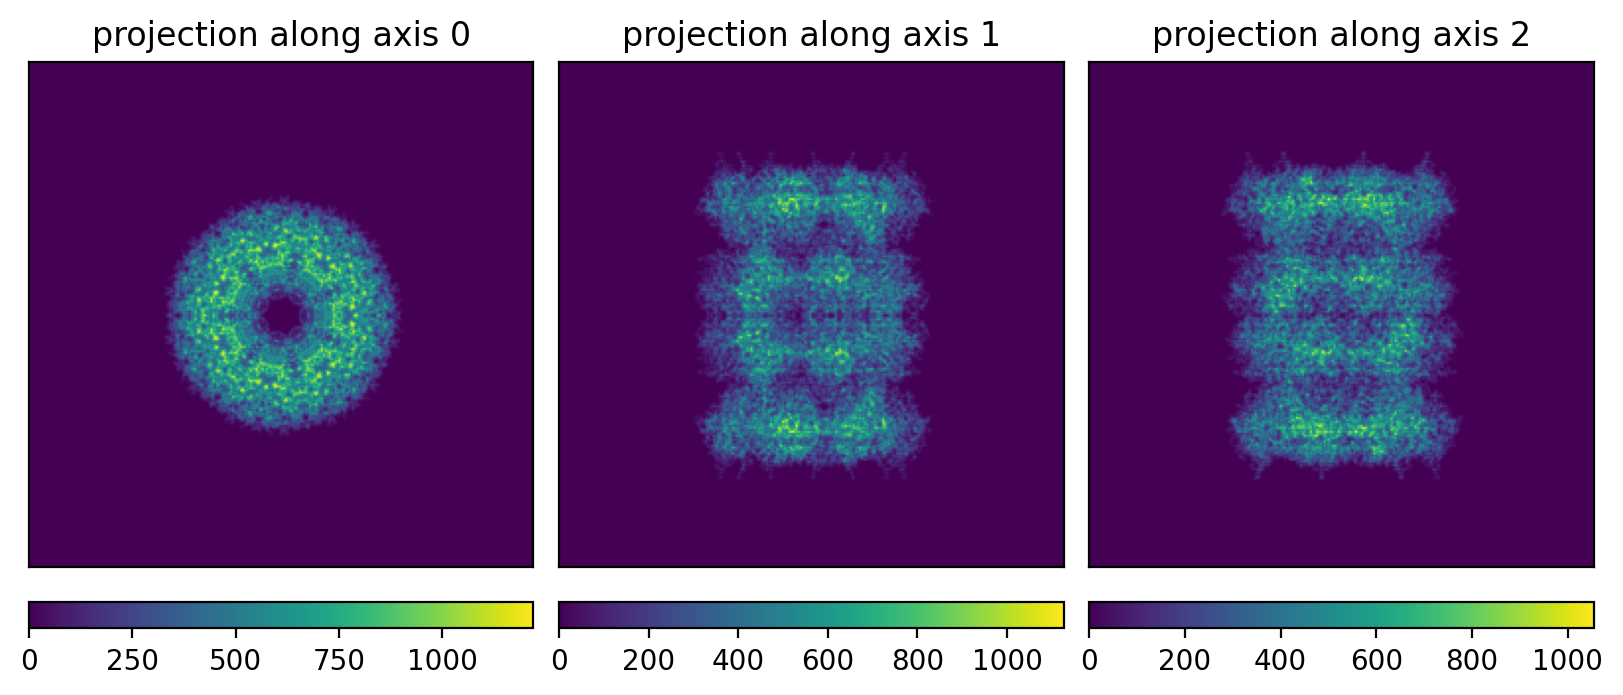

In [20]:
plot3d(vol.detach().cpu())

In [21]:
import torch

from cryosim import rotations
from cryosim.rotations import Rotation

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [22]:
quat = rotations.random_quaternion(2)
quat.shape

torch.Size([2, 4])

In [23]:
R = Rotation.from_quat(quat.clone())

In [24]:
t = torch.tensor([[0.0, 0.0, 0.0], [100.0, 50.0, -60.0]])
T = rotations.translations_angstrom_to_torch(t.clone(), n, dx)
T.shape

torch.Size([2, 3])

In [25]:
centered_coords.shape

torch.Size([46382, 3])

In [26]:
test = R.apply(centered_coords, inverse=True, T=t)

In [27]:
rm = R.as_matrix()
am = rotations.build_affine_matrix(rm, T)

In [28]:
i = 1
new_vol = rotations.rotate_volume(vol.detach().cpu().clone(), am[i].unsqueeze(0))
vol_3d = pb(test[i])

Output()

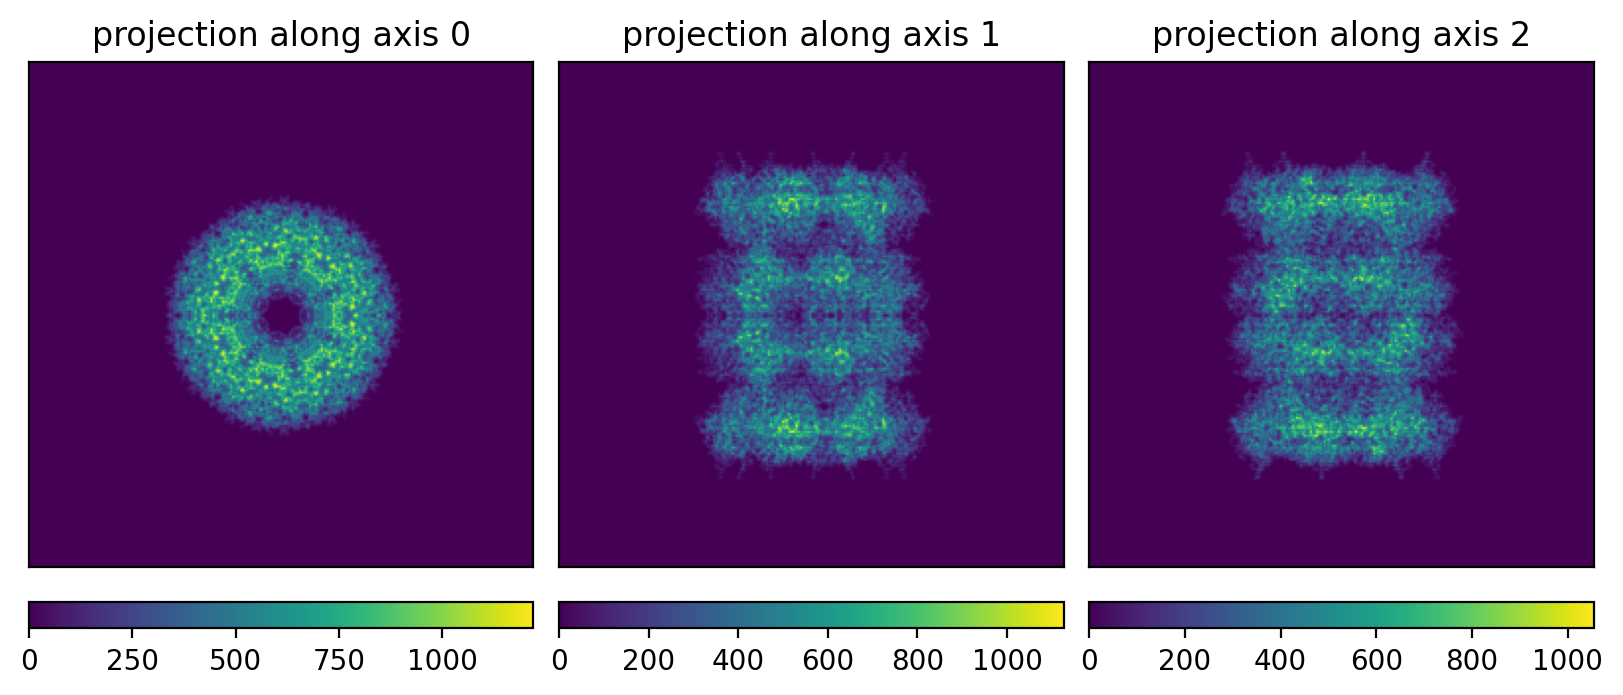

In [29]:
plot3d(vol.detach().cpu())

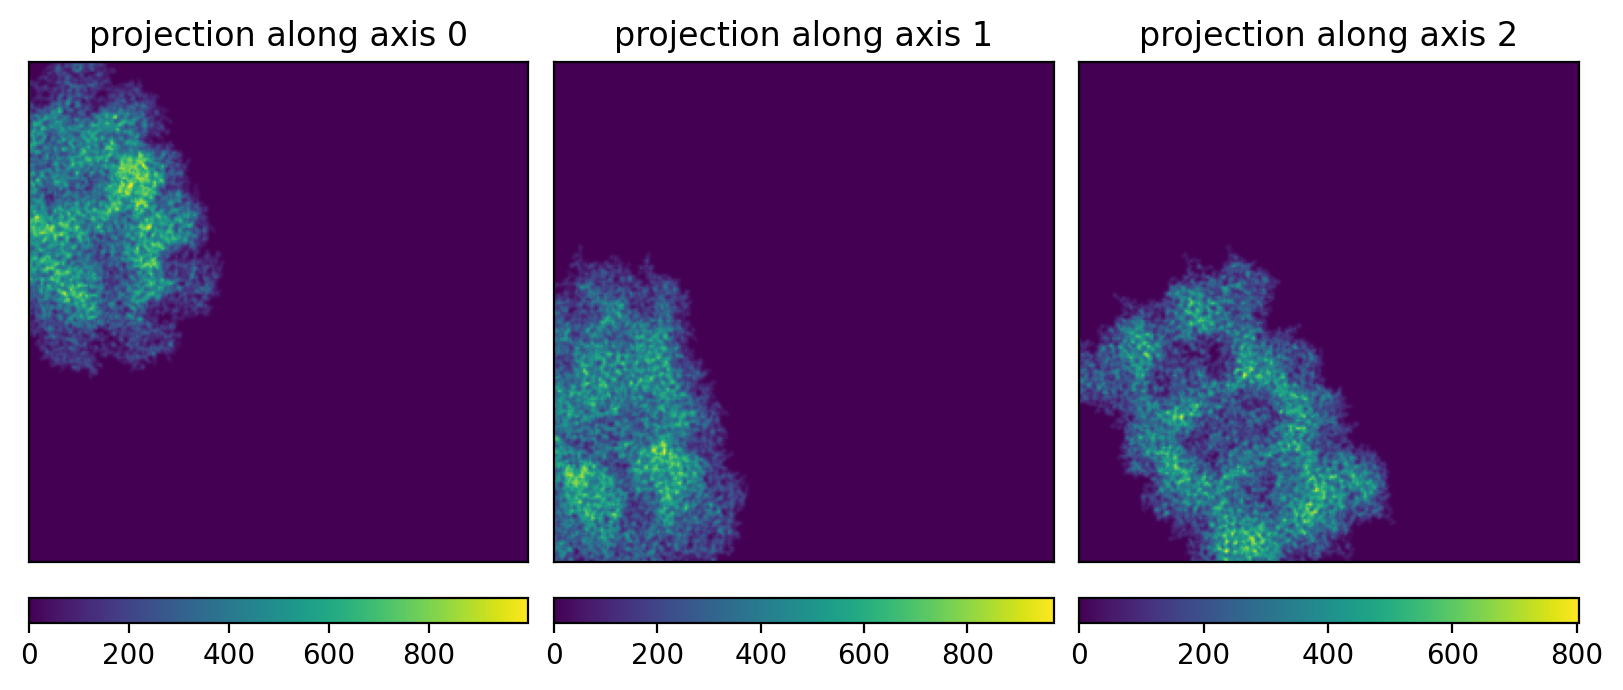

In [30]:
plot3d(new_vol.squeeze())

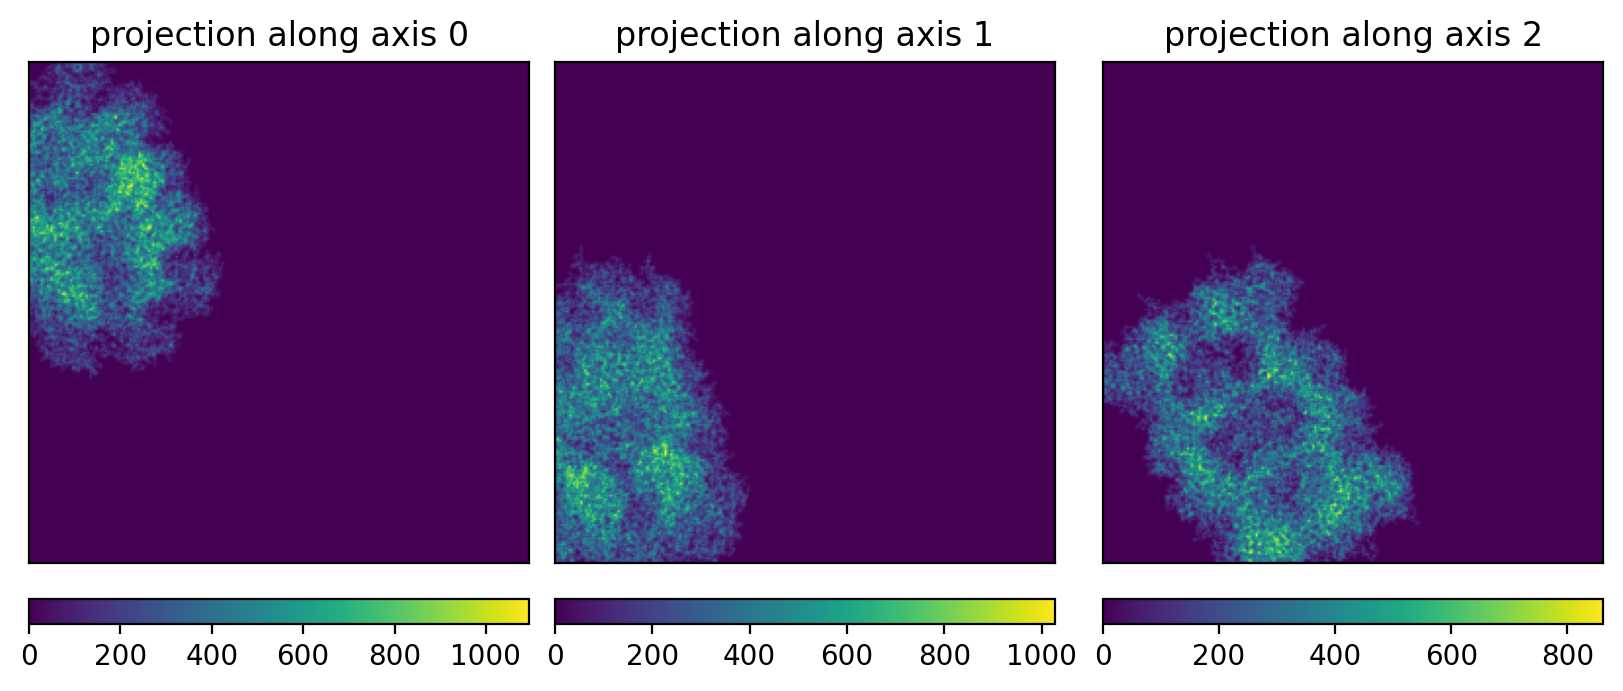

In [31]:
plot3d(vol_3d.detach().cpu())